In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# Your value-added results (6-digit, stream-specific)
venky_df = pd.read_csv("stream_wise_regression_m1_venky.csv")

# Saee’s value-added results (5-digit college-level)
saee_df = pd.read_stata("saee_va_30016base.dta")

# Master mapping dataset
master_df = pd.read_stata("1.5kcolleges_student&collegedetails_v2_limitedvars.dta")


In [5]:
mapping = (
    master_df[["allotted_JC_code", "coll_code_went"]]
    .dropna()
    .drop_duplicates()
)

# normalize formats
mapping["allotted_JC_code"] = mapping["allotted_JC_code"].astype(str).str.lower().str.strip()
mapping["coll_code_went"] = mapping["coll_code_went"].astype(str).str.strip()

print("Mapping rows:", mapping.shape[0])
mapping.head()


Mapping rows: 1846


,allotted_JC_code,coll_code_went
0,,54018.0
1,,56234.0
2,,56024.0
3,508402_bpc,50018.0
4,511901_mpc,42008.0


In [6]:
venky_df = venky_df.rename(columns={
    "college_code": "allotted_JC_code",
    "coef": "venky_VA_stream"
})

venky_df["allotted_JC_code"] = venky_df["allotted_JC_code"].astype(str).str.lower().str.strip()

venky_df = venky_df[["allotted_JC_code", "stream", "venky_VA_stream", "std_err"]].dropna()

print("Your VA rows:", venky_df.shape[0])
venky_df.head()


Your VA rows: 185


,allotted_JC_code,stream,venky_VA_stream,std_err
0,501602_bpc,BPC,-10.258765,4.551773
1,501802_bpc,BPC,9.150848,3.569389
2,502102_bpc,BPC,-6.875228,5.769800
3,502202_bpc,BPC,-10.680327,5.198535
4,502702_bpc,BPC,14.950612,6.799104


In [7]:
saee_df = saee_df.rename(columns={
    "coll_code": "coll_code_went",
    "VA_5": "saee_VA"
})

saee_df["coll_code_went"] = saee_df["coll_code_went"].astype(str).str.strip()

saee_df = saee_df[["coll_code_went", "saee_VA", "stderr_5"]].dropna()

print("Saee VA rows:", saee_df.shape[0])
saee_df.head()


Saee VA rows: 1722


,coll_code_went,saee_VA,stderr_5
0,30001.0,-29.354523,3.134721
1,30002.0,-16.169211,2.632412
2,30003.0,-8.752134,3.097757
3,30004.0,-8.473180,5.773027
4,30005.0,-10.023411,4.580825


In [8]:
# Step 1: your VA (6-digit) → mapping
merged = venky_df.merge(
    mapping,
    on="allotted_JC_code",
    how="left"
)

# Step 2: bring in Saee’s VA (5-digit)
merged = merged.merge(
    saee_df,
    on="coll_code_went",
    how="left"
)

print("Final merged rows:", merged.shape[0])
merged.head()


Final merged rows: 185


,allotted_JC_code,stream,venky_VA_stream,std_err,coll_code_went,saee_VA,stderr_5
0,501602_bpc,BPC,-10.258765,4.551773,33014.0,-7.202116,2.071029
1,501802_bpc,BPC,9.150848,3.569389,31016.0,-3.135446,2.201384
2,502102_bpc,BPC,-6.875228,5.769800,31014.0,-3.437104,2.233295
3,502202_bpc,BPC,-10.680327,5.198535,33023.0,-7.267071,2.296646
4,502702_bpc,BPC,14.950612,6.799104,37012.0,-2.021832,2.316556


In [9]:
print("Streams with Saee match:",
      merged["saee_VA"].notna().sum())

print("Streams without Saee match:",
      merged["saee_VA"].isna().sum())


Streams with Saee match: 185
Streams without Saee match: 0


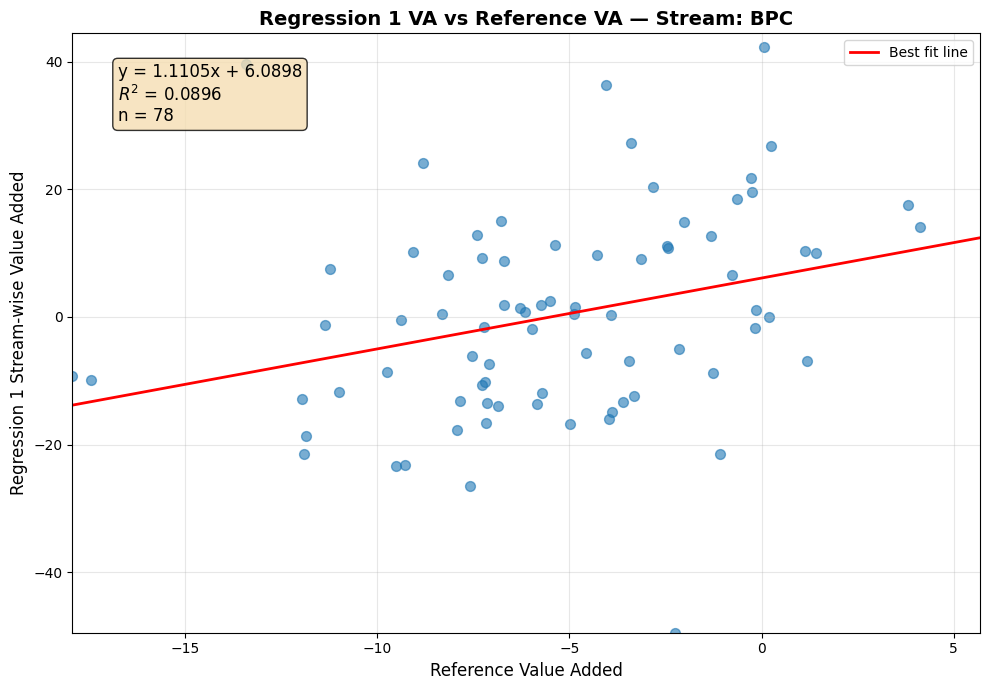

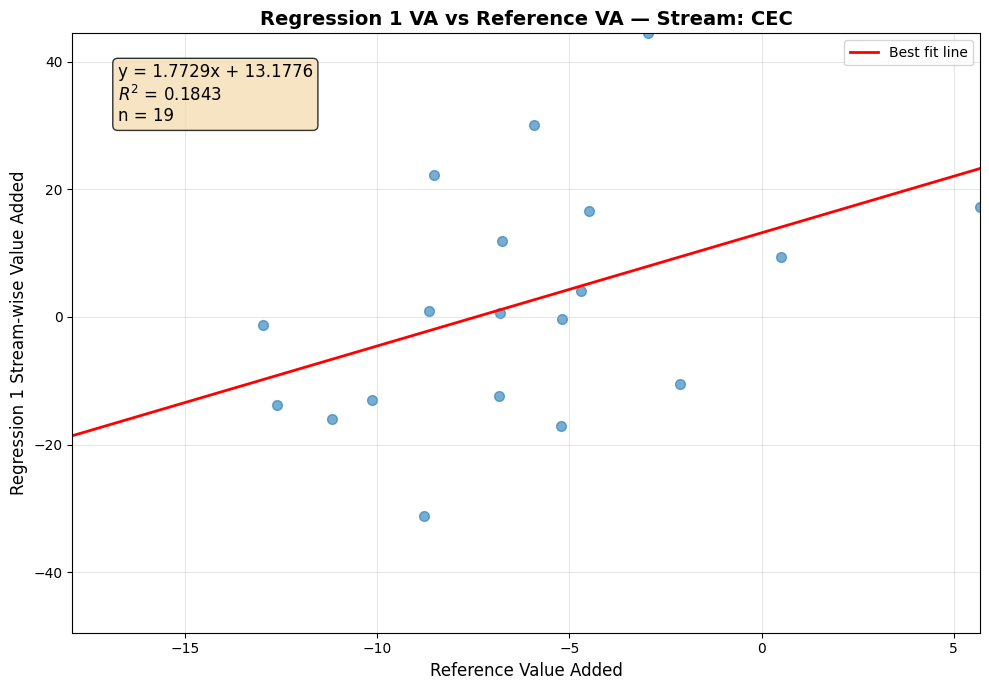

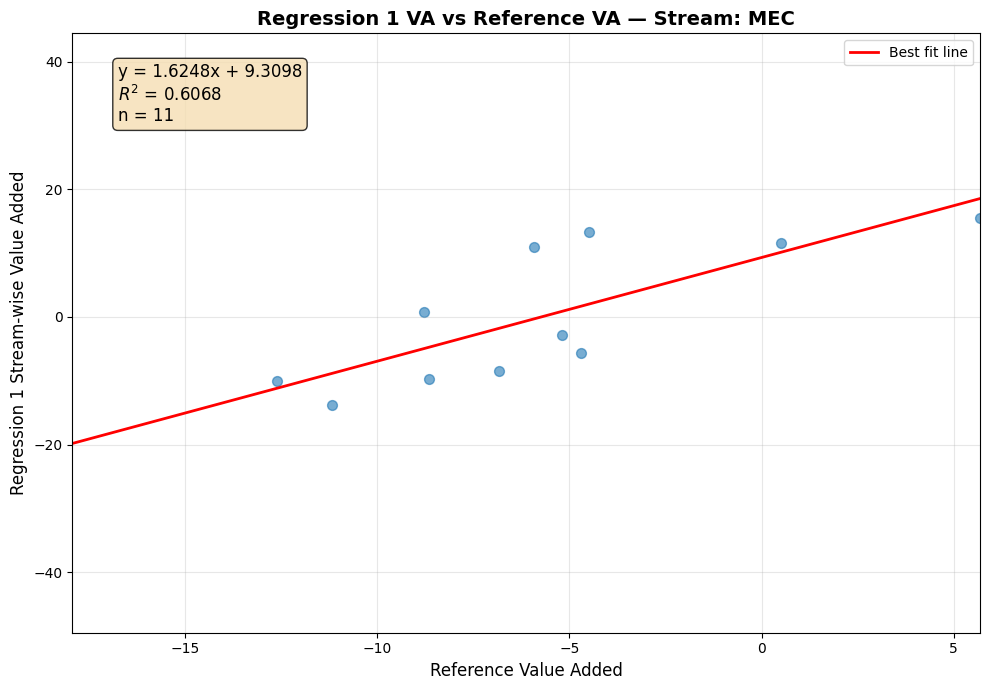

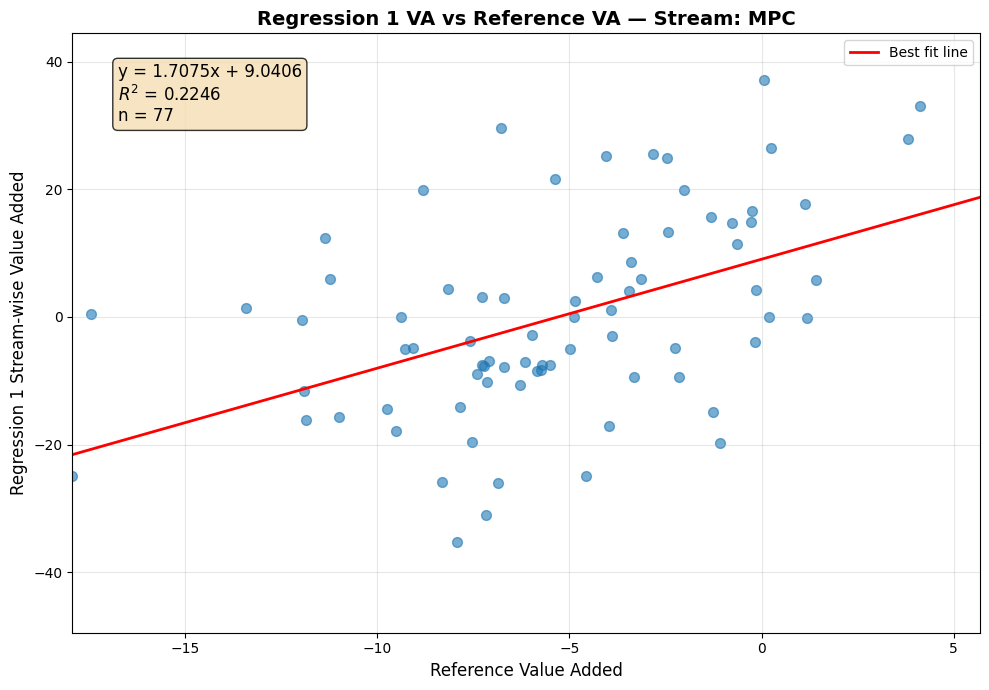

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Compute global axis limits (same scale everywhere) ---
x_min = merged["saee_VA"].min()
x_max = merged["saee_VA"].max()
y_min = merged["venky_VA_stream"].min()
y_max = merged["venky_VA_stream"].max()

streams = sorted(merged["stream"].unique())

# --- 2. Plot stream-wise with regression equations ---
for stream in streams:
    df_s = merged[merged["stream"] == stream]
    x = df_s["saee_VA"].values
    y = df_s["venky_VA_stream"].values
    
    plt.figure(figsize=(10, 7))
    plt.scatter(x, y, alpha=0.6, s=50)
    
    # Best-fit line (OLS)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x_min, x_max, 100)
        y_line = m * x_line + b
        plt.plot(x_line, y_line, 'r-', linewidth=2, label='Best fit line')
        
        # Calculate R-squared
        y_pred = m * x + b
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        # Add regression equation to plot
        equation_text = f'y = {m:.4f}x + {b:.4f}\n$R^2$ = {r_squared:.4f}\nn = {len(x)}'
        plt.text(0.05, 0.95, equation_text, 
                transform=plt.gca().transAxes,
                fontsize=12, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.xlabel("Reference Value Added", fontsize=12)
    plt.ylabel("Regression 1 Stream-wise Value Added", fontsize=12)
    plt.title(f"Regression 1 VA vs Reference VA — Stream: {stream}", fontsize=14, fontweight='bold')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

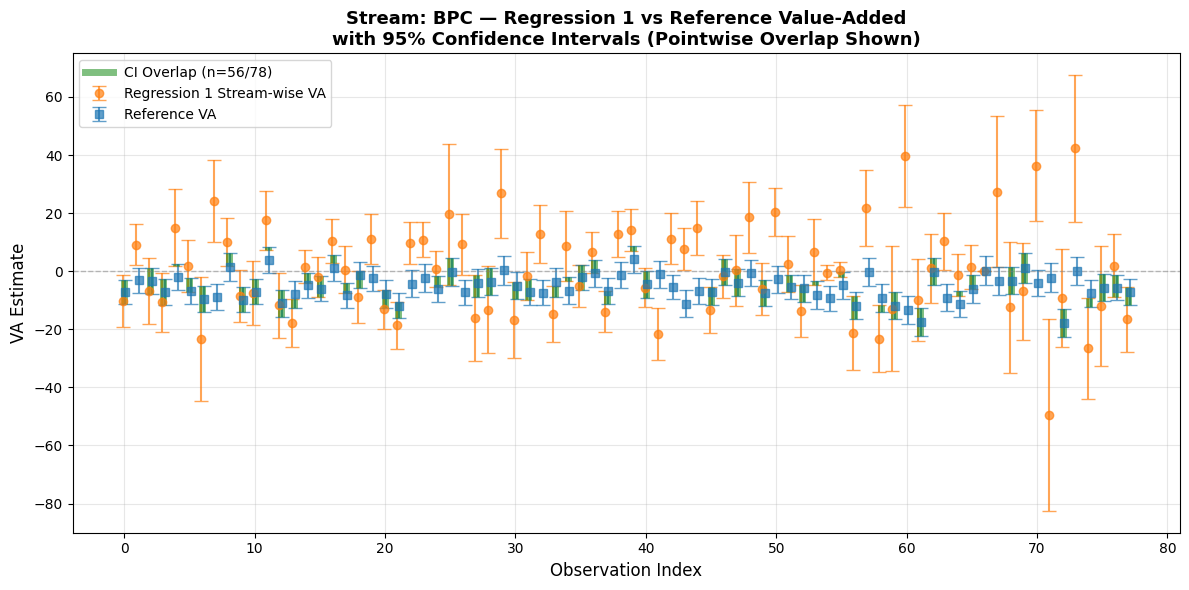


Stream: BPC
  Total observations: 78
  Observations with CI overlap: 56 (71.8%)
  Observations without CI overlap: 22 (28.2%)


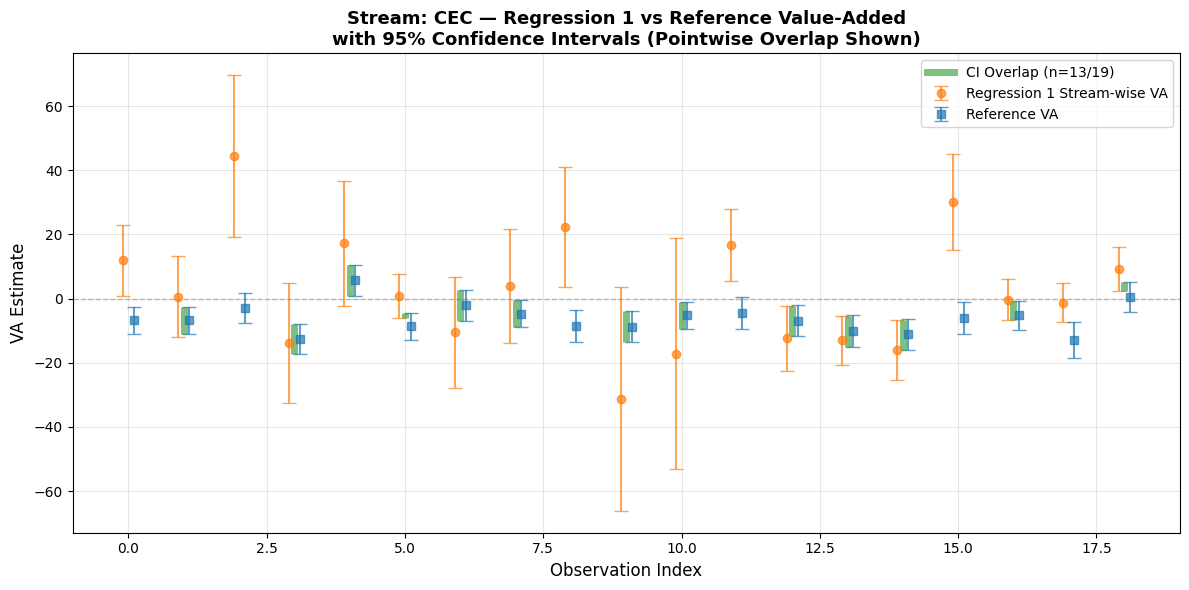


Stream: CEC
  Total observations: 19
  Observations with CI overlap: 13 (68.4%)
  Observations without CI overlap: 6 (31.6%)


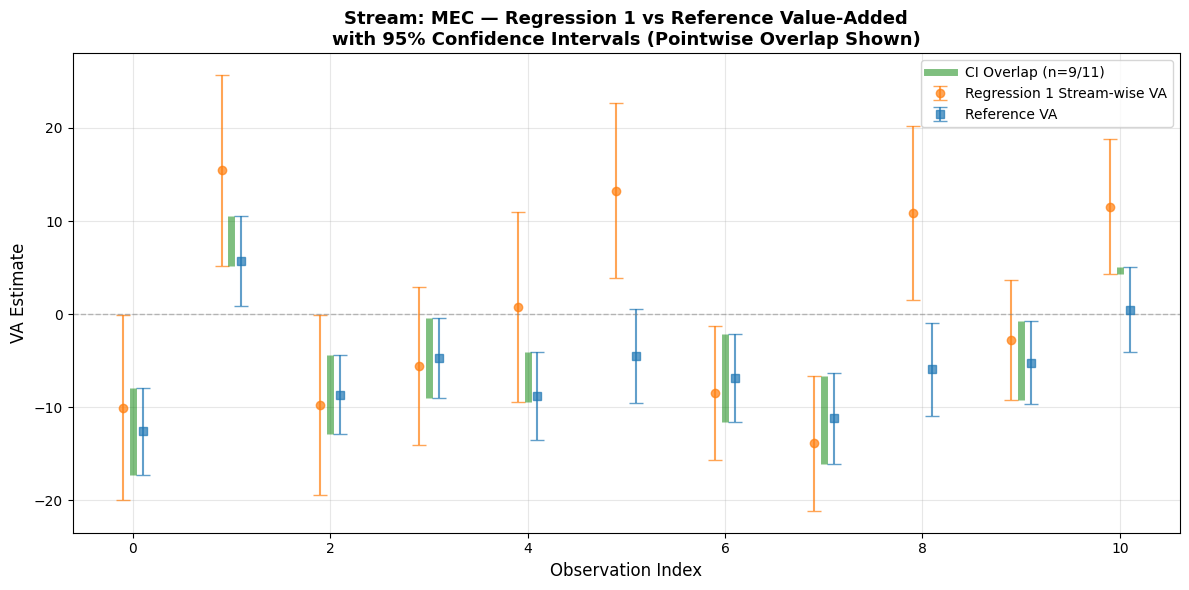


Stream: MEC
  Total observations: 11
  Observations with CI overlap: 9 (81.8%)
  Observations without CI overlap: 2 (18.2%)


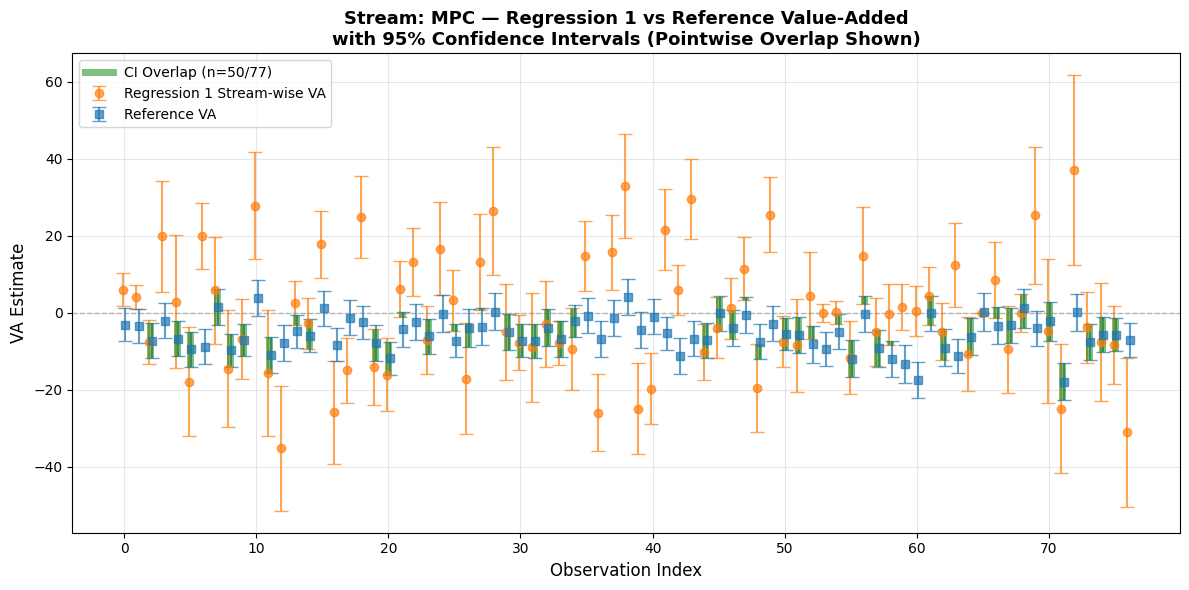


Stream: MPC
  Total observations: 77
  Observations with CI overlap: 50 (64.9%)
  Observations without CI overlap: 27 (35.1%)


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- Pointwise Confidence Interval Plot (Overlap Only) ---

streams = sorted(merged["stream"].unique())

for stream in streams:
    df_s = merged[merged["stream"] == stream].copy()
    
    # X-axis (index or any ordering variable)
    x = np.arange(len(df_s))
    
    # ---- Method 1: venky (Stream-wise) ----
    y1 = df_s['venky_VA_stream'].values
    se1 = df_s['std_err'].values  # Adjust column name if different
    low1 = y1 - 1.96 * se1
    high1 = y1 + 1.96 * se1
    
    # ---- Method 2: saee (Reference) ----
    y2 = df_s['saee_VA'].values
    se2 = df_s['stderr_5'].values  # Adjust column name if different
    low2 = y2 - 1.96 * se2
    high2 = y2 + 1.96 * se2
    
    # ---- Plot ----
    plt.figure(figsize=(12, 6))
    
    # venky_VA (Stream-wise)
    plt.errorbar(
        x - 0.1,
        y1,
        yerr=[y1 - low1, high1 - y1],
        fmt='o',
        capsize=5,
        markersize=6,
        alpha=0.7,
        label='Regression 1 Stream-wise VA',
        color='#ff7f0e'
    )
    
    # saee_VA (Reference)
    plt.errorbar(
        x + 0.1,
        y2,
        yerr=[y2 - low2, high2 - y2],
        fmt='s',
        capsize=5,
        markersize=6,
        alpha=0.7,
        label='Reference VA',
        color='#1f77b4'
    )
    
    # ---- CI overlap (thick line) - ONLY WHERE OVERLAP EXISTS ----
    overlap_low = np.maximum(low1, low2)
    overlap_high = np.minimum(high1, high2)
    
    overlap_count = 0
    for xi, lo, hi in zip(x, overlap_low, overlap_high):
        if hi > lo:  # Only plot where there is actual overlap
            plt.vlines(xi, lo, hi, linewidth=5, alpha=0.5, color='green')
            overlap_count += 1
    
    # Add overlap indicator if any overlaps exist
    if overlap_count > 0:
        # Create a dummy line for legend
        plt.plot([], [], linewidth=5, alpha=0.5, color='green', 
                label=f'CI Overlap (n={overlap_count}/{len(x)})')
    
    # ---- Formatting ----
    plt.axhline(0, linestyle='--', linewidth=1, color='gray', alpha=0.5)
    plt.xlabel('Observation Index', fontsize=12)
    plt.ylabel('VA Estimate', fontsize=12)
    plt.title(f'Stream: {stream} — Regression 1 vs Reference Value-Added\nwith 95% Confidence Intervals (Pointwise Overlap Shown)', 
             fontsize=13, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print overlap statistics
    print(f"\nStream: {stream}")
    print(f"  Total observations: {len(x)}")
    print(f"  Observations with CI overlap: {overlap_count} ({overlap_count/len(x)*100:.1f}%)")
    print(f"  Observations without CI overlap: {len(x) - overlap_count} ({(len(x) - overlap_count)/len(x)*100:.1f}%)")

In [12]:
venky_df_2 = pd.read_csv("venky_va_501502_bpc.csv")

In [13]:
venky_df_2.head()

,college_code,value_added,std_error,p_value
0,501601_mpc,1.190646,0.590301,0.043694
1,501602_bpc,0.840444,0.416157,0.043432
2,501801_mpc,0.504418,0.421540,0.231459
3,501802_bpc,0.894981,0.410170,0.029111
4,501903_mec,-1.930657,0.684271,0.004780


In [14]:
venky_df_2 = venky_df_2.rename(columns={
    "college_code": "allotted_JC_code",
    "value_added": "venky_VA_direct"
})

venky_df_2["allotted_JC_code"] = venky_df_2["allotted_JC_code"].astype(str).str.lower().str.strip()

venky_df_2 = venky_df_2[["allotted_JC_code", "venky_VA_direct", "std_error"]].dropna()

print("Your VA rows:", venky_df_2.shape[0])
venky_df_2.head()

Your VA rows: 192


,allotted_JC_code,venky_VA_direct,std_error
0,501601_mpc,1.190646,0.590301
1,501602_bpc,0.840444,0.416157
2,501801_mpc,0.504418,0.421540
3,501802_bpc,0.894981,0.410170
4,501903_mec,-1.930657,0.684271


In [15]:
stream_v_direct = venky_df.merge(
    venky_df_2,
    on="allotted_JC_code",
    how="inner"   # inner is correct: only colleges with both estimates
)

print("Final merged rows:", stream_v_direct.shape[0])
stream_v_direct.head()



Final merged rows: 185


,allotted_JC_code,stream,venky_VA_stream,std_err,venky_VA_direct,std_error
0,501602_bpc,BPC,-10.258765,4.551773,0.840444,0.416157
1,501802_bpc,BPC,9.150848,3.569389,0.894981,0.410170
2,502102_bpc,BPC,-6.875228,5.769800,0.253836,0.404114
3,502202_bpc,BPC,-10.680327,5.198535,-3.880314,0.604999
4,502702_bpc,BPC,14.950612,6.799104,3.423504,0.742586


In [16]:
x_min = stream_v_direct["venky_VA_direct"].min()
x_max = stream_v_direct["venky_VA_direct"].max()
y_min = stream_v_direct["venky_VA_stream"].min()
y_max = stream_v_direct["venky_VA_stream"].max()


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


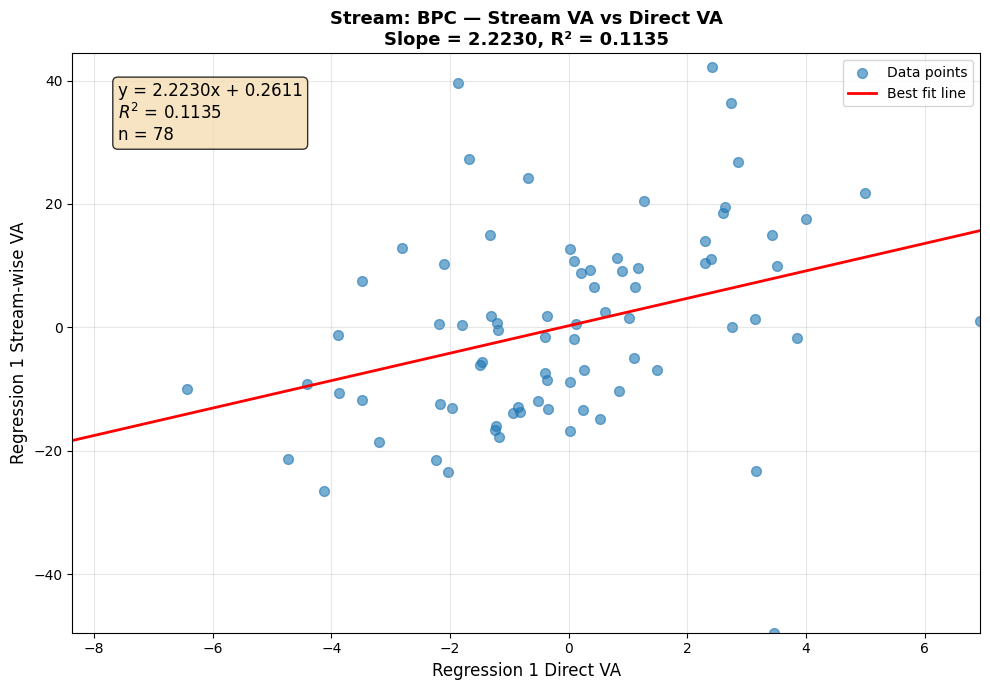

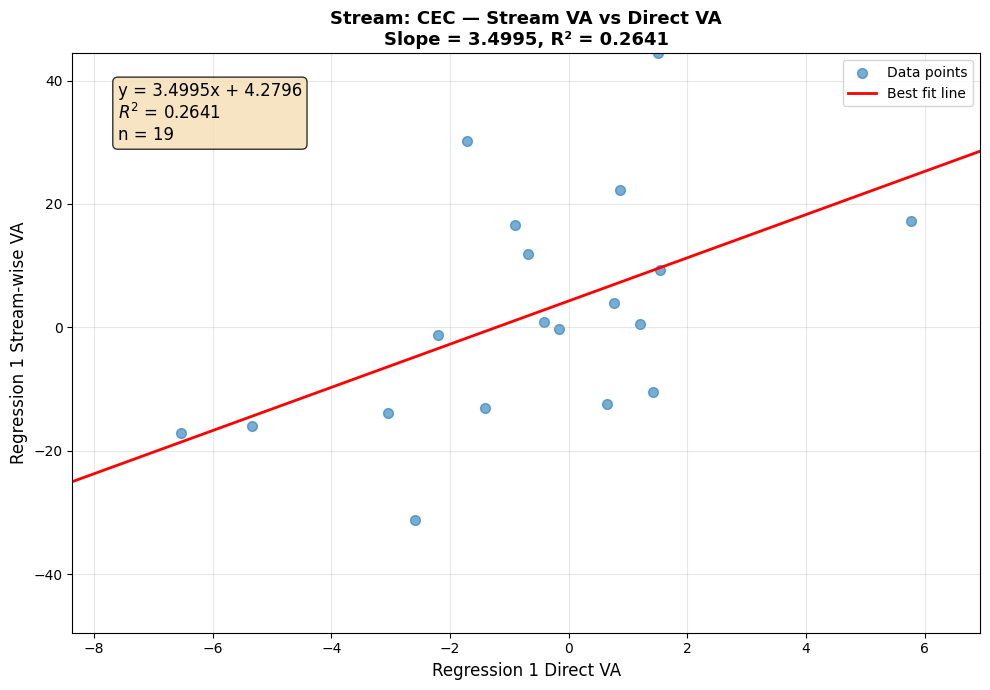

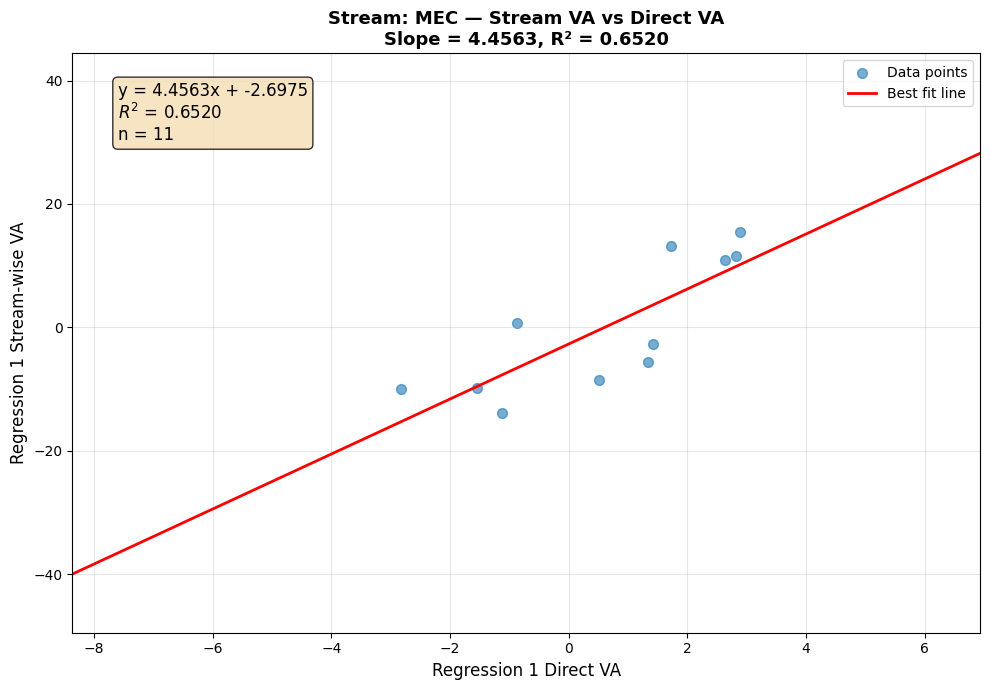

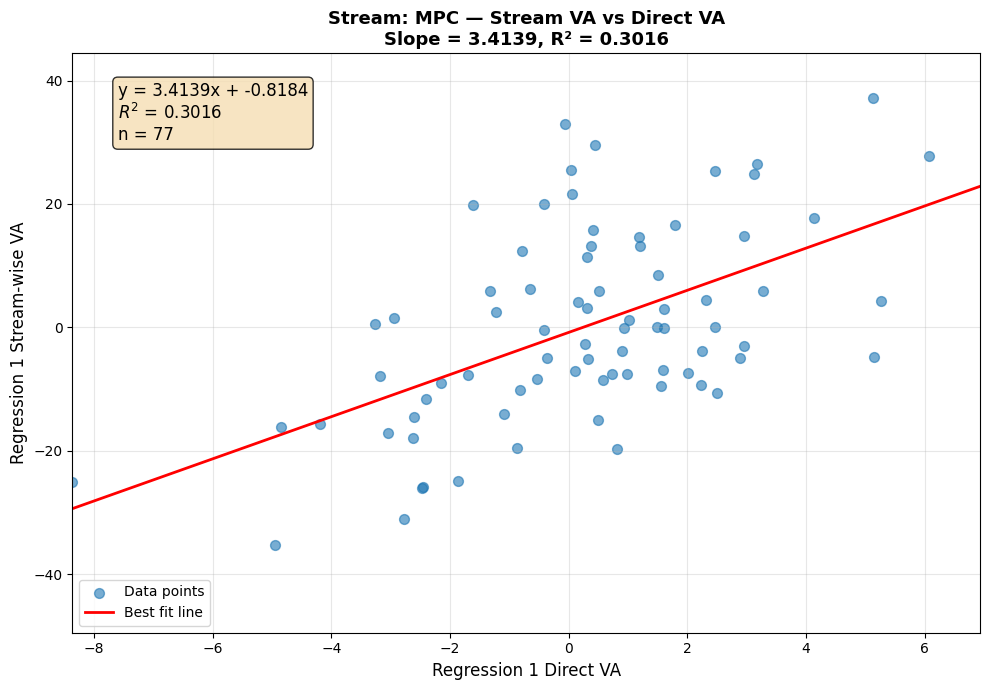

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- 1. Compute global axis limits ---
x_min = stream_v_direct["venky_VA_direct"].min()
x_max = stream_v_direct["venky_VA_direct"].max()
y_min = stream_v_direct["venky_VA_stream"].min()
y_max = stream_v_direct["venky_VA_stream"].max()

streams = sorted(stream_v_direct["stream"].unique())

# --- 2. Regression plots with equations ---
for stream in streams:
    df_s = stream_v_direct[stream_v_direct["stream"] == stream]
    x = df_s["venky_VA_direct"]
    y = df_s["venky_VA_stream"]
    
    # OLS regression
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    
    # Plot
    plt.figure(figsize=(10, 7))
    plt.scatter(x, y, alpha=0.6, s=50, label='Data points')
    
    x_line = np.linspace(x_min, x_max, 100)
    y_line = model.params["const"] + model.params["venky_VA_direct"] * x_line
    plt.plot(x_line, y_line, 'r-', linewidth=2, label='Best fit line')
    
    # Add regression equation to plot
    slope = model.params["venky_VA_direct"]
    intercept = model.params["const"]
    r_squared = model.rsquared
    n = len(x)
    
    equation_text = (f'y = {slope:.4f}x + {intercept:.4f}\n'
                    f'$R^2$ = {r_squared:.4f}\n'
                    f'n = {n}')
    plt.text(0.05, 0.95, equation_text, 
            transform=plt.gca().transAxes,
            fontsize=12, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.xlabel("Regression 1 Direct VA", fontsize=12)
    plt.ylabel("Regression 1 Stream-wise VA", fontsize=12)
    plt.title(
        f"Stream: {stream} — Stream VA vs Direct VA\n"
        f"Slope = {slope:.4f}, R² = {r_squared:.4f}",
        fontsize=13, fontweight='bold'
    )
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

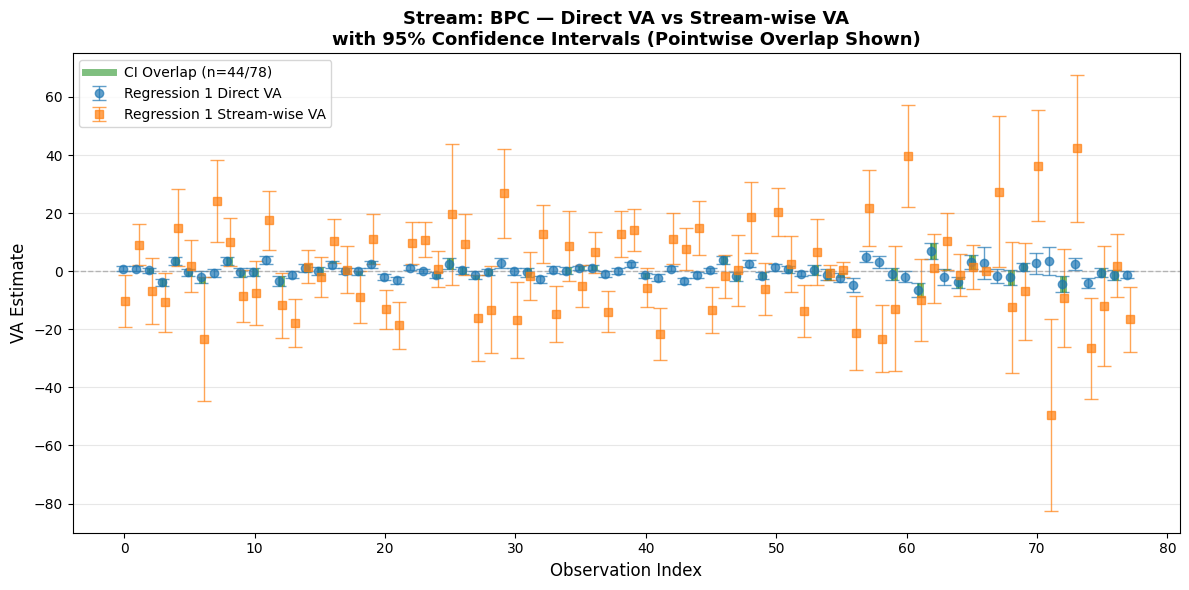


Stream: BPC
  Total observations: 78
  Observations with CI overlap: 44 (56.4%)
  Observations without CI overlap: 34 (43.6%)


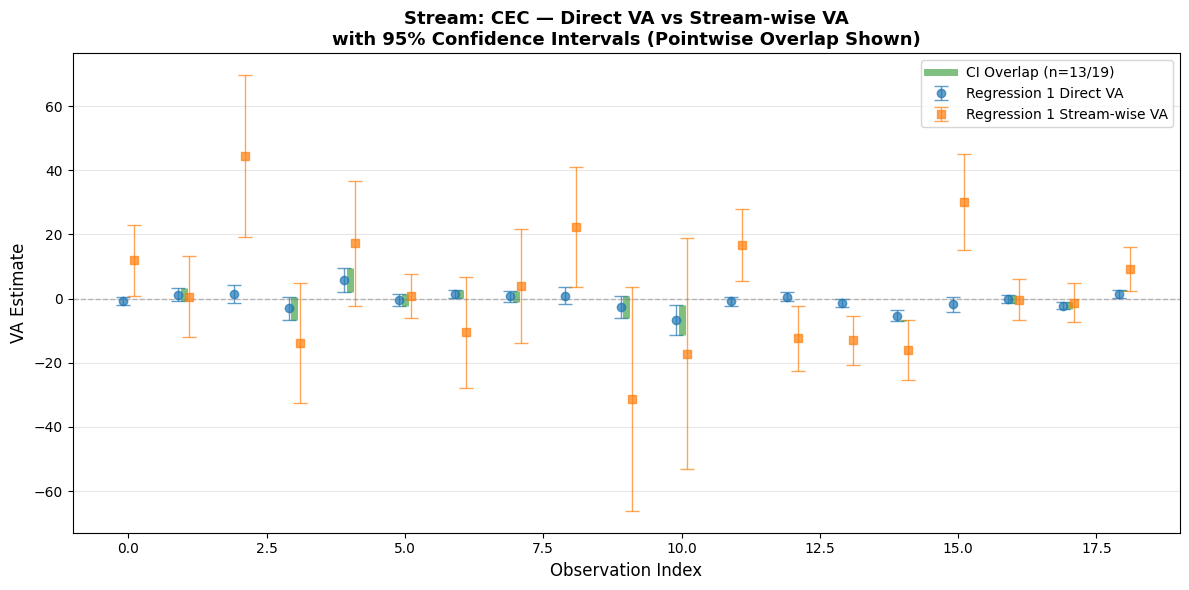


Stream: CEC
  Total observations: 19
  Observations with CI overlap: 13 (68.4%)
  Observations without CI overlap: 6 (31.6%)


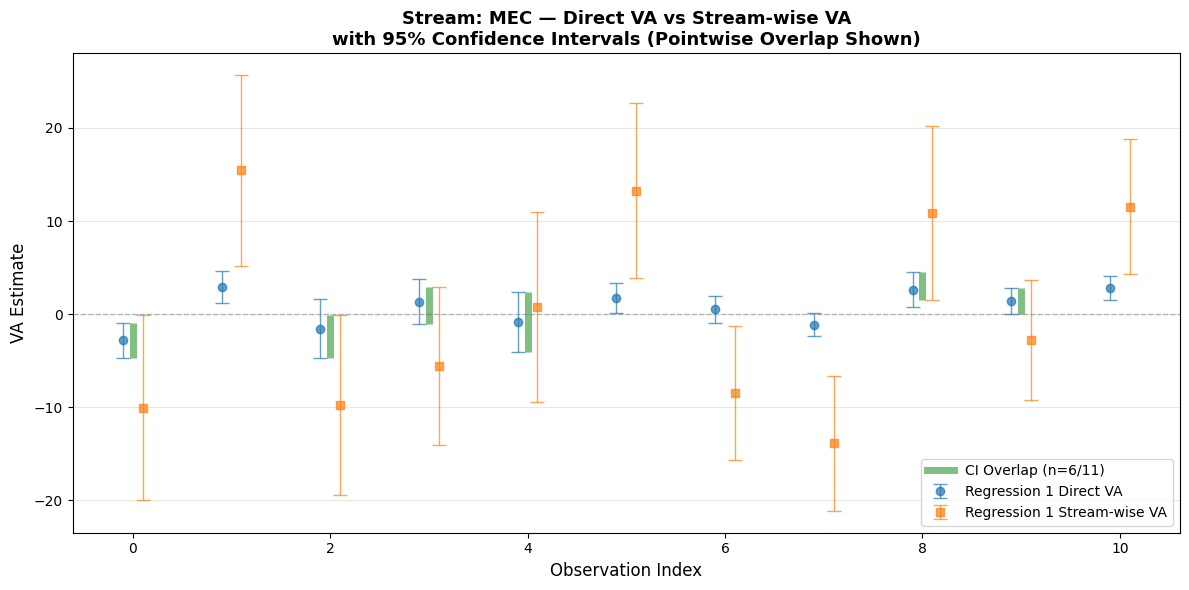


Stream: MEC
  Total observations: 11
  Observations with CI overlap: 6 (54.5%)
  Observations without CI overlap: 5 (45.5%)


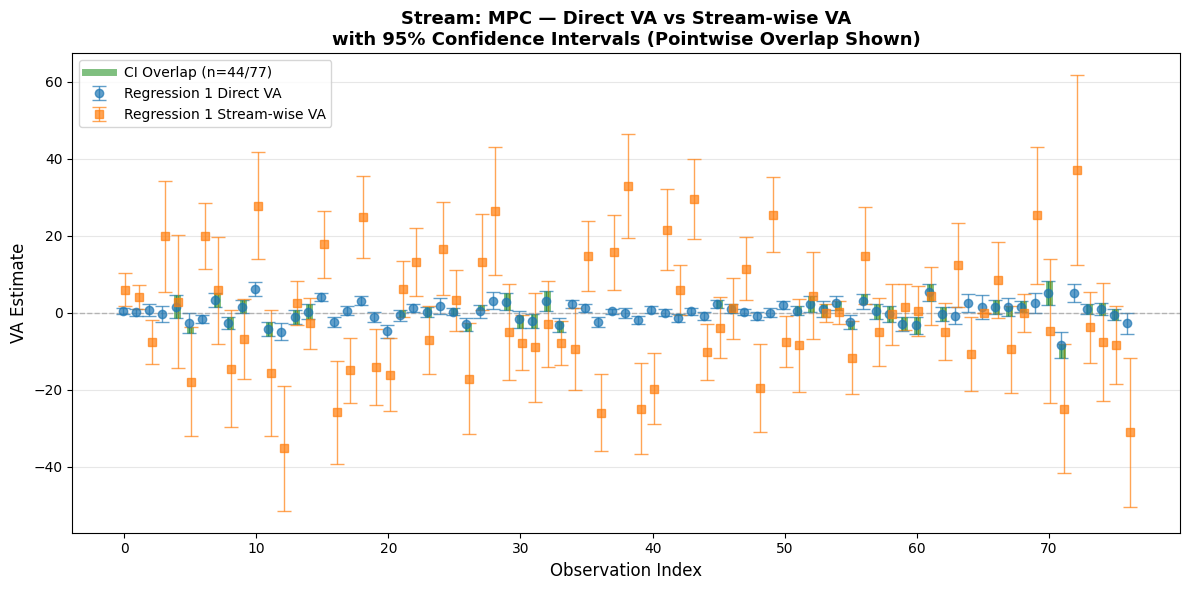


Stream: MPC
  Total observations: 77
  Observations with CI overlap: 44 (57.1%)
  Observations without CI overlap: 33 (42.9%)


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# --- 3. Pointwise Confidence Interval Plot (Overlap Only) ---

streams = sorted(stream_v_direct["stream"].unique())

for stream in streams:
    df_s = stream_v_direct[stream_v_direct["stream"] == stream].copy()
    
    # X-axis (index or any ordering variable)
    x = np.arange(len(df_s))
    
    # ---- Method 1: Direct VA ----
    y1 = df_s['venky_VA_direct'].values
    se1 = df_s['std_error'].values  # Adjust column name if different
    low1 = y1 - 1.96 * se1
    high1 = y1 + 1.96 * se1
    
    # ---- Method 2: Stream-wise VA ----
    y2 = df_s['venky_VA_stream'].values
    se2 = df_s['std_err'].values  # Adjust column name if different
    low2 = y2 - 1.96 * se2
    high2 = y2 + 1.96 * se2
    
    # ---- Plot ----
    plt.figure(figsize=(12, 6))
    
    # Direct VA
    plt.errorbar(
        x - 0.1,
        y1,
        yerr=[y1 - low1, high1 - y1],
        fmt='o',
        capsize=5,
        markersize=6,
        alpha=0.7,
        label='Regression 1 Direct VA',
        color='#1f77b4',
        elinewidth=1
    )
    
    # Stream-wise VA
    plt.errorbar(
        x + 0.1,
        y2,
        yerr=[y2 - low2, high2 - y2],
        fmt='s',
        capsize=5,
        markersize=6,
        alpha=0.7,
        label='Regression 1 Stream-wise VA',
        color='#ff7f0e',
        elinewidth=1
    )
    
    # ---- CI overlap (thick line) - ONLY WHERE OVERLAP EXISTS ----
    overlap_low = np.maximum(low1, low2)
    overlap_high = np.minimum(high1, high2)
    
    overlap_count = 0
    for xi, lo, hi in zip(x, overlap_low, overlap_high):
        if hi > lo:  # Only plot where there is actual overlap
            plt.vlines(xi, lo, hi, linewidth=5, alpha=0.5, color='green')
            overlap_count += 1
    
    # Add overlap indicator if any overlaps exist
    if overlap_count > 0:
        # Create a dummy line for legend
        plt.plot([], [], linewidth=5, alpha=0.5, color='green', 
                label=f'CI Overlap (n={overlap_count}/{len(x)})')
    
    # ---- Formatting ----
    plt.axhline(0, linestyle='--', linewidth=1, color='gray', alpha=0.5)
    plt.xlabel('Observation Index', fontsize=12)
    plt.ylabel('VA Estimate', fontsize=12)
    plt.title(f'Stream: {stream} — Direct VA vs Stream-wise VA\nwith 95% Confidence Intervals (Pointwise Overlap Shown)', 
             fontsize=13, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Print overlap statistics
    print(f"\nStream: {stream}")
    print(f"  Total observations: {len(x)}")
    print(f"  Observations with CI overlap: {overlap_count} ({overlap_count/len(x)*100:.1f}%)")
    print(f"  Observations without CI overlap: {len(x) - overlap_count} ({(len(x) - overlap_count)/len(x)*100:.1f}%)")